# STAR Protocol

### Paper code
Load data and anlysis

In [107]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [108]:
%load_ext autoreload
%autoreload 2
from photom import Photom


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Example with a single file. It reads the data from a binary ppd file and preprocesses the data.

In [109]:
photom = Photom("/Users/hakan/Library/CloudStorage/Dropbox/Amelia/Circadian/STAR-Protocol/020219-2-2019-09-17-161002.ppd",
                signal_channel = "analog_1",
                control_channel = "analog_2",
                low_pass = 5,           # low_pass
                high_pass = 0.0001,     # high_pass
                preprocess=True,        # Preprocess the data
                median_filter = 21, 
                downsample_factor = 2,   # Downsample from 10 Hz to 5 Hz 
                downsample_method = "mean",
                bleach_correct = True,
                motion_correct = True,
                normalization = "z-score",
                timeseries = True,
                as_df = True
                )


Preprocessing data...


UnboundLocalError: cannot access local variable 'sampling_rate' where it is not associated with a value

Plot the results.

Text(0, 0.5, 'Normalized Signal (z-score)')

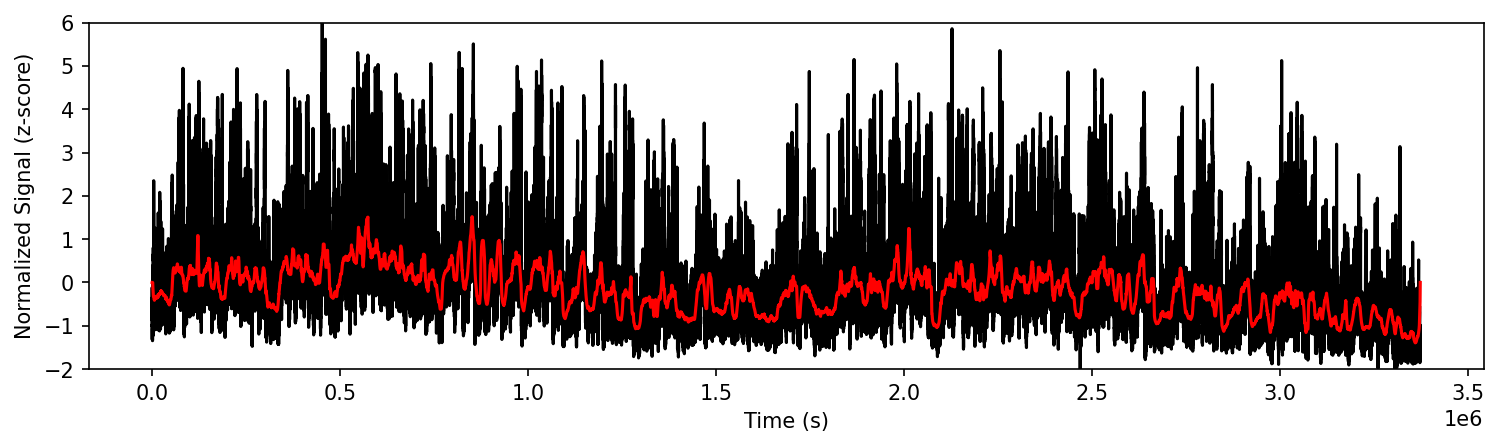

In [100]:
fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=150)
ax.plot(photom.data["signal_norm"], c="black", lw=0.8)

signal_slow = photom.apply_filters(signals=["signal_norm"], median=photom.sampling_rate*60*10) # 10 min median filter
ax.plot(signal_slow+np.nanmean(photom.data["signal_norm"]), color="tomato", lw=2)

ax.set_ylim(-2, 6)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Signal (z-score)")


In [112]:
duration = 90
duration * photom.sampling_rate



1800